# 0. Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

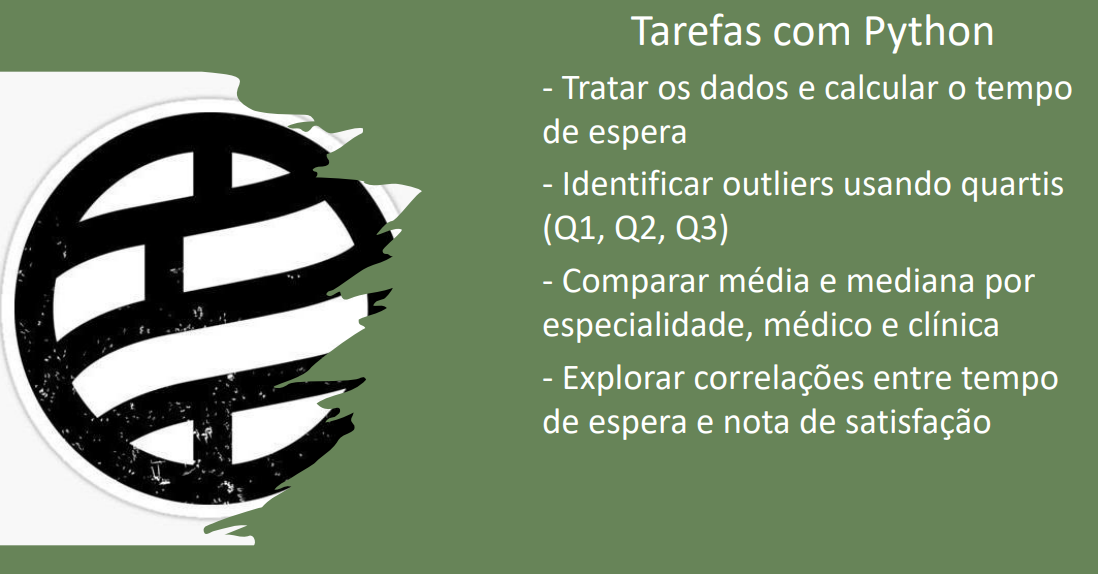

# 1. Tratamento de dados (Analisando tabelas)

In [2]:
# CSV Avaliações
dfAvaliacoes = pd.read_csv('avaliacoes.csv', sep = ',')
dfAvaliacoes.head()

,id_consulta,nota_satisfacao,comentario
0,697,4,Comentário 1
1,34,1,Comentário 2
2,9,4,Comentário 3
3,1254,1,Comentário 4
4,4180,4,Comentário 5


In [3]:
dfAvaliacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_consulta      100 non-null    int64 
 1   nota_satisfacao  100 non-null    int64 
 2   comentario       100 non-null    object
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [4]:
dfAvaliacoes.isna().sum()

id_consulta        0
nota_satisfacao    0
comentario         0
dtype: int64

In [5]:
# CSV Clinicas
dfClinicas = pd.read_csv('clinicas.csv')
dfClinicas.head()

,id_clinica,nome,cidade,capacidade_diaria
0,1,Bem Viver,Curitiba,73
1,2,Clínica Vital,São Paulo,78
2,3,Clínica Vital,Curitiba,37
3,4,Bem Viver,Belo Horizonte,76
4,5,Clínica São Lucas,Curitiba,92


In [6]:
dfClinicas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_clinica         100 non-null    int64 
 1   nome               100 non-null    object
 2   cidade             100 non-null    object
 3   capacidade_diaria  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB


In [7]:
dfClinicas.isna().sum()

id_clinica           0
nome                 0
cidade               0
capacidade_diaria    0
dtype: int64

In [8]:
# CSV Consultas
dfConsultas = pd.read_csv('consultas.csv')
dfConsultas.head()

,id_consulta,id_paciente,id_medico,id_clinica,especialidade,Tempo de espera,status
0,1,82,15,4,Cardiologia,30,Realizada
1,2,18,95,14,Cardiologia,240,Realizada
2,3,55,5,4,Pediatria,15,Realizada
3,4,78,4,72,Ortopedia,240,Realizada
4,5,58,76,36,Pediatria,0,Cancelada


In [9]:
dfConsultas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_consulta      5000 non-null   int64 
 1   id_paciente      5000 non-null   int64 
 2   id_medico        5000 non-null   int64 
 3   id_clinica       5000 non-null   int64 
 4   especialidade    5000 non-null   object
 5   Tempo de espera  5000 non-null   int64 
 6   status           5000 non-null   object
dtypes: int64(5), object(2)
memory usage: 273.6+ KB


In [10]:
dfConsultas.isna().sum()

id_consulta        0
id_paciente        0
id_medico          0
id_clinica         0
especialidade      0
Tempo de espera    0
status             0
dtype: int64

In [11]:
#CSV Medicos
dfMedicos = pd.read_csv('medicos.csv')
dfMedicos.head()

,id_medico,nome,especialidade,tempo_medio_atendimento
0,1,Dr(a). Fernanda Gomes,Neurologia,35
1,2,Dr(a). Ricardo Souza,Oftalmologia,39
2,3,Dr(a). Juliana Oliveira,Neurologia,34
3,4,Dr(a). Mariana Nascimento,Oftalmologia,18
4,5,Dr(a). Mariana Almeida,Pediatria,39


In [12]:
dfMedicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id_medico                100 non-null    int64 
 1   nome                     100 non-null    object
 2   especialidade            100 non-null    object
 3   tempo_medio_atendimento  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB


In [13]:
dfMedicos.isna().sum()

id_medico                  0
nome                       0
especialidade              0
tempo_medio_atendimento    0
dtype: int64

In [14]:
#CSV Pacientes
dfPacientes = pd.read_csv('pacientes.csv')
dfPacientes.head()

,id_paciente,idade,sexo,cidade,plano_saude
0,1,21,M,Manaus,Sim
1,2,15,M,Brasília,Sim
2,3,86,M,Salvador,Não
3,4,87,M,Manaus,Sim
4,5,56,M,Porto Alegre,Não


In [15]:
dfPacientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_paciente  100 non-null    int64 
 1   idade        100 non-null    int64 
 2   sexo         100 non-null    object
 3   cidade       100 non-null    object
 4   plano_saude  100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


In [16]:
dfPacientes.isna().sum()

id_paciente    0
idade          0
sexo           0
cidade         0
plano_saude    0
dtype: int64

Conclui-se que não há valores vazios nos arquivos CSV

# 2. Identificando quartis e outliers no tempo de espera

In [17]:
# Removendo consultas não realizadas
dfConsultasRealizadas = dfConsultas[dfConsultas['status'] != 'Cancelada']
dfConsultasRealizadas.head()

,id_consulta,id_paciente,id_medico,id_clinica,especialidade,Tempo de espera,status
0,1,82,15,4,Cardiologia,30,Realizada
1,2,18,95,14,Cardiologia,240,Realizada
2,3,55,5,4,Pediatria,15,Realizada
3,4,78,4,72,Ortopedia,240,Realizada
5,6,21,90,55,Dermatologia,30,Realizada


In [18]:
array_Tempo_de_Espera = np.array(dfConsultasRealizadas['Tempo de espera'])

In [19]:
# Calculando estatística descritiva
media = np.mean(array_Tempo_de_Espera)
mediana = np.median(array_Tempo_de_Espera)
Q1 = np.quantile(array_Tempo_de_Espera, 0.25)
Q2 = np.quantile(array_Tempo_de_Espera, 0.5)
Q3 = np.quantile(array_Tempo_de_Espera, 0.75)
IQR = Q3 - Q1
Ls = Q3 + IQR * 1.5
Li = Q1 - IQR * 1.5


In [20]:
print(f'A média para o tempo de espera é de {media:.2f} minutos.')
print(f'A mediana para o tempo de espera é de {mediana:.2f} minutos.')
print(f'O 1º quartil para o tempo de espera é {Q1}')
print(f'O 3º quartil para o tempo de espera é {Q3}')
print(f'O limite superior para o tempo de espera é {Ls:.2f}')
print(f'O limite inferior para o tempo de espera é {Li:.2f}')

A média para o tempo de espera é de 95.41 minutos.
A mediana para o tempo de espera é de 30.00 minutos.
O 1º quartil para o tempo de espera é 10.0
O 3º quartil para o tempo de espera é 180.0
O limite superior para o tempo de espera é 435.00
O limite inferior para o tempo de espera é -245.00


In [21]:
# Identificando outliers
OutlierSuperior = dfConsultasRealizadas.loc[dfConsultasRealizadas['Tempo de espera'] > Ls]
OutlierSuperior

,id_consulta,id_paciente,id_medico,id_clinica,especialidade,Tempo de espera,status


Não há outliers superiores

In [22]:
OutlierInferior = dfConsultasRealizadas.loc[dfConsultasRealizadas['Tempo de espera'] < Li]
OutlierInferior

,id_consulta,id_paciente,id_medico,id_clinica,especialidade,Tempo de espera,status


Não há outliers inferiores

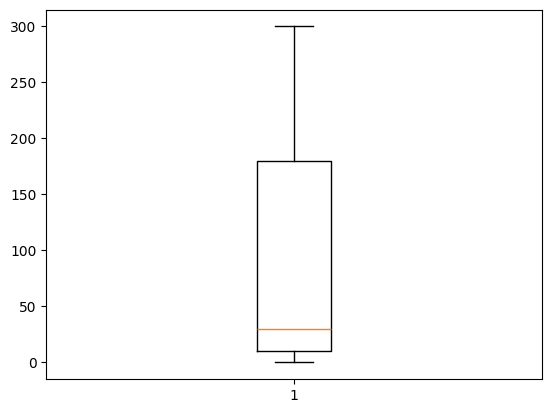

In [23]:
plt.boxplot(array_Tempo_de_Espera)
plt.show()

Não há outliers.

# 3. Analisando média e medianas por especialidade, médico e clinica

In [24]:
# Analisando por especialidade
MediaEspecialidade = dfConsultasRealizadas.groupby('especialidade')['Tempo de espera'].mean().reset_index().sort_values(by='Tempo de espera', ascending=False)
MediaEspecialidade

,especialidade,Tempo de espera
5,Pediatria,96.460880
0,Cardiologia,95.820136
3,Neurologia,95.323944
1,Dermatologia,95.280612
4,Ortopedia,94.717195
2,Ginecologia,94.587087


In [25]:
MedianaEspecialidade = dfConsultasRealizadas.groupby('especialidade')['Tempo de espera'].median().reset_index().sort_values(by='Tempo de espera', ascending=False)
MedianaEspecialidade

,especialidade,Tempo de espera
0,Cardiologia,60.0
1,Dermatologia,60.0
3,Neurologia,60.0
4,Ortopedia,45.0
2,Ginecologia,30.0
5,Pediatria,30.0


In [26]:
AtendimentoMedico= pd.merge(dfConsultasRealizadas[['id_medico','Tempo de espera']], dfMedicos[['id_medico','nome']], on = 'id_medico', how='inner')
AtendimentoMedico

,id_medico,Tempo de espera,nome
0,15,30,Dr(a). Ricardo Lima
1,95,240,Dr(a). Ricardo Costa
2,5,15,Dr(a). Mariana Almeida
3,4,240,Dr(a). Mariana Nascimento
4,90,30,Dr(a). Patrícia Souza
...,...,...,...
3994,20,10,Dr(a). Carlos Lima
3995,26,15,Dr(a). Ricardo Silva
3996,39,0,Dr(a). Patrícia Gomes
3997,7,120,Dr(a). Fernanda Oliveira


In [27]:
# Analisando por médico
MediaMedico = AtendimentoMedico.groupby('nome')['Tempo de espera'].mean().reset_index().sort_values(by='Tempo de espera', ascending=False)
MediaMedico

,nome,Tempo de espera
15,Dr(a). Carlos Costa,123.214286
36,Dr(a). João Rodrigues,116.379310
55,Dr(a). Ricardo Lima,115.925926
56,Dr(a). Ricardo Nascimento,112.435897
32,Dr(a). Fernanda Rodrigues,111.283784
30,Dr(a). Fernanda Oliveira,110.989011
17,Dr(a). Carlos Lima,107.743902
45,Dr(a). Mariana Silva,107.195122
39,Dr(a). Juliana Pereira,107.028986
19,Dr(a). Carlos Oliveira,105.875000


In [28]:
MedianaMedico = AtendimentoMedico.groupby('nome')['Tempo de espera'].median().reset_index().sort_values(by='Tempo de espera', ascending=False)
MedianaMedico

,nome,Tempo de espera
15,Dr(a). Carlos Costa,90.0
0,Dr(a). André Almeida,60.0
16,Dr(a). Carlos Gomes,60.0
33,Dr(a). Fernanda Souza,60.0
32,Dr(a). Fernanda Rodrigues,60.0
39,Dr(a). Juliana Pereira,60.0
30,Dr(a). Fernanda Oliveira,60.0
40,Dr(a). Mariana Almeida,60.0
41,Dr(a). Mariana Costa,60.0
44,Dr(a). Mariana Oliveira,60.0


In [29]:
AtendimentoClinica= pd.merge(dfConsultasRealizadas[['id_clinica','Tempo de espera']], dfClinicas[['id_clinica','nome']], on = 'id_clinica', how='inner')
AtendimentoClinica

,id_clinica,Tempo de espera,nome
0,4,30,Bem Viver
1,14,240,Clínica Esperança
2,4,15,Bem Viver
3,72,240,Bem Viver
4,55,30,Clínica Renova
...,...,...,...
3994,51,10,Clínica Horizonte
3995,8,15,Vida Plena
3996,34,0,Clínica Vital
3997,98,120,Clínica Horizonte


In [30]:
# Analisando por clínica
MediaClinica = AtendimentoClinica.groupby('nome')['Tempo de espera'].mean().reset_index().sort_values(by='Tempo de espera', ascending=False)
MediaClinica

,nome,Tempo de espera
6,Clínica São Lucas,102.244898
4,Clínica Nova Vida,100.470914
5,Clínica Renova,99.060694
3,Clínica Horizonte,97.961730
0,Bem Viver,95.431373
2,Clínica Esperança,94.001866
7,Clínica Vital,92.965328
9,Vida Plena,91.228070
1,Clínica Bem Estar,89.541667
8,Saúde Total,88.820896


In [31]:
MedianaClinica = AtendimentoClinica.groupby('nome')['Tempo de espera'].median().reset_index().sort_values(by='Tempo de espera', ascending=False)
MedianaClinica

,nome,Tempo de espera
0,Bem Viver,60.0
3,Clínica Horizonte,60.0
4,Clínica Nova Vida,60.0
5,Clínica Renova,60.0
1,Clínica Bem Estar,30.0
2,Clínica Esperança,30.0
6,Clínica São Lucas,30.0
7,Clínica Vital,30.0
8,Saúde Total,30.0
9,Vida Plena,30.0


# 4. Correlações entre tempo de espera e nota de satisfação

In [32]:
Df =  pd.merge(dfConsultasRealizadas, dfAvaliacoes, on='id_consulta', how='inner')
Df

,id_consulta,id_paciente,id_medico,id_clinica,especialidade,Tempo de espera,status,nota_satisfacao,comentario
0,9,69,16,49,Ortopedia,240,Realizada,4,Comentário 3
1,34,11,94,63,Pediatria,5,Remarcada,1,Comentário 2
2,85,34,23,75,Ortopedia,0,Realizada,1,Comentário 97
3,231,80,72,42,Pediatria,300,Realizada,2,Comentário 60
4,298,65,50,60,Pediatria,240,Remarcada,3,Comentário 59
...,...,...,...,...,...,...,...,...,...
76,4743,79,71,42,Neurologia,300,Realizada,5,Comentário 14
77,4874,52,88,93,Ortopedia,0,Realizada,5,Comentário 29
78,4880,99,27,99,Pediatria,15,Realizada,2,Comentário 96
79,4916,85,19,39,Cardiologia,60,Realizada,2,Comentário 44


In [33]:
dfCorrelacao = Df[['id_consulta','Tempo de espera','nota_satisfacao']]
dfCorrelacao

,id_consulta,Tempo de espera,nota_satisfacao
0,9,240,4
1,34,5,1
2,85,0,1
3,231,300,2
4,298,240,3
...,...,...,...
76,4743,300,5
77,4874,0,5
78,4880,15,2
79,4916,60,2


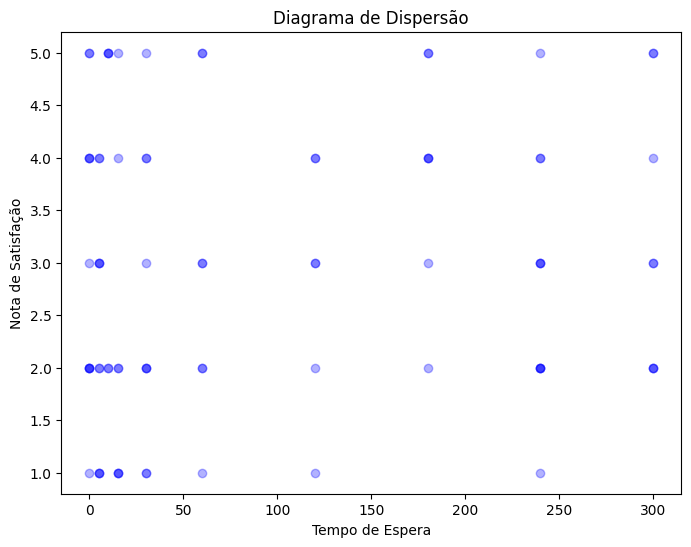

In [34]:
x = np.array(dfCorrelacao['Tempo de espera'])
y = np.array(dfCorrelacao['nota_satisfacao'])

plt.figure(figsize= (8,6))
plt.scatter(x, y, color = 'blue', alpha=0.3)
plt.title('Diagrama de Dispersão')
plt.xlabel('Tempo de Espera')
plt.ylabel('Nota de Satisfação')
plt.show()

In [35]:
correlacao = np.corrcoef(x, y)
coef = correlacao[0,1]
print(coef)

0.11384644269479813


Através do Gráfico de Dispersão e do Coeficiente de Pearson, nota-se que não há correlação entre o Tempo de Espera e a Nota de Satisfação do cliente.